# PGD: Projected Gradient Descent on Raw Audio Waveforms

`attacks/whitebox/01_FGSM.ipynb` takes a single signed gradient step. PGD, the iterative refinement Madry et
al. (2018) showed to be a far stronger first-order adversary, takes many small steps, each
projected back into the $\varepsilon$-ball around the original waveform. Same relationship as
`attacks/whitebox/02_PGD.ipynb` in the vision repo, just with amplitude samples standing in for pixels:

$$x_{t+1} = \Pi_{x + \mathcal{B}_\varepsilon} \left( x_t + \alpha \cdot \text{sign}(\nabla_x J(\theta, x_t, y)) \right)$$

The expectation, exactly as in the vision repo, is that PGD reaches a higher Attack Success Rate
than FGSM at the same $\varepsilon$ budget, since it can correct course instead of committing to a
single gradient-sign direction.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import soundfile as sf
import pandas as pd
import matplotlib.pyplot as plt

torch.manual_seed(0)

def _load_wav(path, frame_offset=0, num_frames=-1, normalize=True, channels_first=True, format=None, buffer_size=4096, backend=None):
    """Replaces torchaudio's TorchCodec-based loader (needs a separately installed FFmpeg, not
    available here) with soundfile, which reads WAV directly with no extra system dependencies."""
    data, sample_rate = sf.read(path, dtype='float32')
    waveform = torch.from_numpy(data)
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(1)
    if channels_first:
        waveform = waveform.transpose(0, 1)
    return waveform, sample_rate

torchaudio.load = _load_wav

### Setup: Load the Trained Keyword Spotter
Identical loading code to `attacks/whitebox/01_FGSM.ipynb`, same target model.

In [2]:
LABELS = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
SAMPLE_RATE = 16000

mel_spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate=SAMPLE_RATE, n_mels=64, n_fft=400, hop_length=160)
to_db = torchaudio.transforms.AmplitudeToDB()

def waveform_to_spectrogram(waveform):
    return to_db(mel_spectrogram(waveform))

class KeywordCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, spectrogram):
        x = self.pool(F.relu(self.bn1(self.conv1(spectrogram))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x).flatten(1)
        return self.fc(x)

model = KeywordCNN(num_classes=len(LABELS))
model.load_state_dict(torch.load('../models/keyword_spotter.pth', map_location='cpu'))
model.eval()
print("Loaded keyword_spotter.pth")

Loaded keyword_spotter.pth


### Setup: Test Clips
Same 10 held-out test clips (one per class) attacked in `attacks/whitebox/01_FGSM.ipynb`, for a direct,
apples-to-apples ASR/SNR comparison at matched $\varepsilon$.

In [3]:
import os

LABEL_TO_IDX = {label: i for i, label in enumerate(LABELS)}

os.makedirs('../models/speech_commands_data', exist_ok=True)
test_data = torchaudio.datasets.SPEECHCOMMANDS(root='../models/speech_commands_data', download=True, subset='testing')

def pad_or_trim(waveform):
    if waveform.shape[1] < SAMPLE_RATE:
        return F.pad(waveform, (0, SAMPLE_RATE - waveform.shape[1]))
    return waveform[:, :SAMPLE_RATE]

sample_clips = {}
for i in range(len(test_data)):
    waveform, sr, label, *_ = test_data[i]
    if label in LABEL_TO_IDX and label not in sample_clips:
        sample_clips[label] = pad_or_trim(waveform)
    if len(sample_clips) == len(LABELS):
        break

print(f"Collected {len(sample_clips)} sample clips, one per class")

Collected 10 sample clips, one per class


### The Attack
10 steps, step size $\alpha = \varepsilon / (\text{iters} / 2)$, the same convention used
throughout the vision repo's PGD implementation. Each step is projected back into the
$L_\infty$ ball of radius $\varepsilon$ around the original waveform, then clipped to the
valid $[-1, 1]$ amplitude range.

In [4]:
def pgd_attack(waveform, true_label_idx, epsilon, iters=10):
    alpha = epsilon / (iters / 2.0)
    adv_waveform = waveform.clone()
    for _ in range(iters):
        adv_waveform = adv_waveform.clone().requires_grad_(True)
        logits = model(waveform_to_spectrogram(adv_waveform.unsqueeze(0)))
        loss = F.cross_entropy(logits, torch.tensor([true_label_idx]))
        loss.backward()
        adv_waveform = adv_waveform + alpha * adv_waveform.grad.sign()
        perturbation = torch.clamp(adv_waveform - waveform, -epsilon, epsilon)
        adv_waveform = torch.clamp(waveform + perturbation, -1.0, 1.0).detach()
    return adv_waveform

def predict(waveform):
    with torch.no_grad():
        logits = model(waveform_to_spectrogram(waveform.unsqueeze(0)))
        probs = F.softmax(logits, dim=-1)[0]
        label_idx = int(torch.argmax(probs))
    return LABELS[label_idx], float(probs[label_idx]), label_idx

### Evaluation: Attack Success Rate vs. $\varepsilon$
Same $\varepsilon$ grid and SNR metric as `attacks/whitebox/01_FGSM.ipynb`, so the two results are directly
comparable in the summary at the end.

In [5]:
EPSILONS = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

def snr_db(clean, adv):
    noise_power = float(torch.sum((adv - clean) ** 2))
    signal_power = float(torch.sum(clean ** 2))
    if noise_power == 0:
        return float('inf')
    return 10 * torch.log10(torch.tensor(signal_power / noise_power)).item()

results = []
for label, waveform in sample_clips.items():
    true_idx = LABEL_TO_IDX[label]
    orig_label, orig_prob, orig_idx = predict(waveform)
    if orig_idx != true_idx:
        continue

    for epsilon in EPSILONS:
        adv_waveform = pgd_attack(waveform, true_idx, epsilon)
        adv_label, adv_prob, adv_idx = predict(adv_waveform)
        results.append({
            'Label': label, 'Epsilon': epsilon,
            'Success': adv_idx != true_idx, 'SNR_dB': snr_db(waveform, adv_waveform),
        })

results_df = pd.DataFrame(results)
results_df.to_csv('pgd_audio_results.csv', index=False)
print(results_df.groupby('Epsilon')[['Success', 'SNR_dB']].mean())

         Success     SNR_dB
Epsilon                    
0.001        1.0  40.933761
0.005        1.0  27.023731
0.010        1.0  21.094181
0.020        1.0  15.201129
0.050        1.0   7.275023
0.100        1.0   1.248856


### Plot: FGSM vs. PGD, ASR at Matched $\varepsilon$
The comparison this notebook exists to make: does the extra compute of 10 iterative steps buy a
meaningfully higher Attack Success Rate at the same perturbation budget, the same question asked
of images in the vision repo, now asked of waveforms.

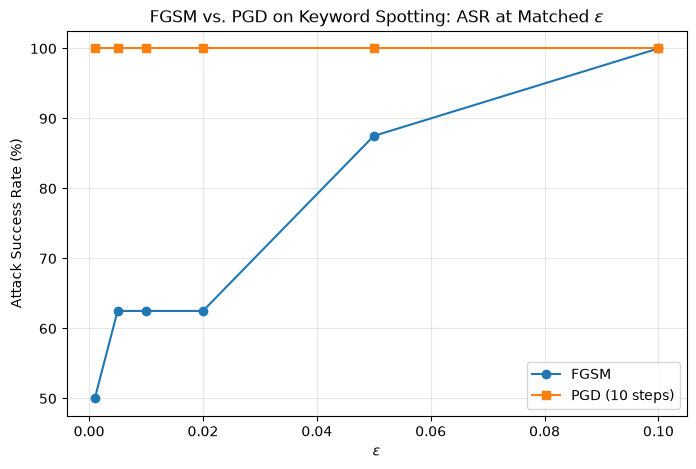

In [6]:
fgsm_df = pd.read_csv('../attacks/fgsm_audio_results.csv')
fgsm_summary = fgsm_df.groupby('Epsilon')['Success'].mean() * 100
pgd_summary = results_df.groupby('Epsilon')['Success'].mean() * 100

plt.figure(figsize=(8, 5))
plt.plot(fgsm_summary.index, fgsm_summary.values, 'o-', label='FGSM')
plt.plot(pgd_summary.index, pgd_summary.values, 's-', label='PGD (10 steps)')
plt.xlabel('$\\varepsilon$')
plt.ylabel('Attack Success Rate (%)')
plt.title('FGSM vs. PGD on Keyword Spotting: ASR at Matched $\\varepsilon$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()